# Installation des packages

In [42]:
# Installation des packages si absent
packages <- c("tidyverse", "readxl", "corrplot", "GGally",
              "compositions", "FactoMineR", "factoextra",
              "car", "lmtest")

installed <- rownames(installed.packages())
to_install <- packages[!packages %in% installed]

if (length(to_install) > 0) {
  install.packages(to_install)
}

In [43]:
library(tidyverse)
library(readxl)
library(corrplot)
library(GGally)

# Chargement
df <- read_csv("data/data.csv") %>%
  select(-1) %>%
  rename(Cadre = Cadres, Artisan = Artisant, Txcho = txcho, TxAbs = txabs)

glimpse(df)
summary(df)

New names:
• `` -> `...1`
Rows: 96 Columns: 15
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (2): Department, Code
dbl (13): ...1, HLM, Salairemoy, Ouvrier, Employe, PI, Cadres, Artisant, Agr...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Rows: 96
Columns: 14
$ Department <chr> "Ain", "Aisne", "Allier", "Alpes-de-Haute-Provence", "Haute…
$ Code       <chr> "1", "2", "3", "4", "5", "6", "7", "8", "9", "10", "11", "1…
$ HLM        <dbl> 14.4, 16.0, 10.8, 7.6, 11.3, 8.8, 7.5, 18.0, 4.5, 19.6, 8.2…
$ Salairemoy <dbl> 13.58, 12.52, 12.10, 12.73, 12.04, 14.22, 12.65, 12.60, 12.…
$ Ouvrier    <dbl> 27.4, 28.6, 24.7, 19.6, 18.9, 15.5, 23.4, 29.2, 20.6, 26.6,…
$ Employe    <dbl> 26.3, 30.5, 32.2, 30.0, 32.4, 31.1, 28.4, 29.3, 31.4, 29.0,…
$ PI         <dbl> 25.3, 22.6, 22.3, 25.7, 26.6, 25.2, 24.0, 22.7, 24.8, 23.7,…
$ Cadre      <dbl> 11.8, 9.6, 9.2, 10.7, 9.4, 17.6, 10.5, 9.7, 9.6, 10.6, 10.5…
$ Artisan    <dbl> 7.5, 6.1, 7.4, 10.4, 9.8, 10.2, 10.1, 6.2, 9.5, 6.3, 10.1, …
$ Agri       <dbl> 1.7, 2.6, 4.3, 3.6, 2.9, 0.4, 3.6, 3.0, 4.1, 3.8, 4.0, 8.7,…
$ TxPauv     <dbl> 10.8, 18.7, 15.4, 17.0, 14.5, 16.0, 14.7, 19.4, 18.2, 15.6,…
$ NonDiplome <dbl> 29.4, 39.9, 36.4, 31.3, 28.4, 31.6, 33.8, 39.1, 33.6, 38.1,…
$ Txcho      <dbl> 

  Department            Code                HLM          Salairemoy   
 Length:96          Length:96          Min.   : 4.50   Min.   :11.29  
 Class :character   Class :character   1st Qu.: 8.75   1st Qu.:12.29  
 Mode  :character   Mode  :character   Median :11.90   Median :12.71  
                                       Mean   :12.68   Mean   :13.24  
                                       3rd Qu.:15.32   3rd Qu.:13.59  
                                       Max.   :32.40   Max.   :22.16  
    Ouvrier         Employe            PI            Cadre      
 Min.   : 8.10   Min.   :20.50   Min.   :20.70   Min.   : 8.20  
 1st Qu.:20.15   1st Qu.:27.85   1st Qu.:23.38   1st Qu.: 9.80  
 Median :23.05   Median :28.90   Median :24.80   Median :11.30  
 Mean   :22.85   Mean   :28.89   Mean   :24.80   Mean   :13.32  
 3rd Qu.:26.45   3rd Qu.:30.35   3rd Qu.:26.43   3rd Qu.:14.72  
 Max.   :30.80   Max.   :34.10   Max.   :28.90   Max.   :42.20  
    Artisan            Agri            TxPauv   

## Plan de travail

**Problématique** : Quels facteurs socio-économiques expliquent les variations du taux d'abstention entre départements français lors des élections présidentielles 2017 ?

**Données** : 96 départements, 13 variables issues de l'INSEE, DADS, Filosofi et du Ministère de l'Intérieur. Périodes 2014-2017. Aucune valeur manquante.

**Démarche** :
1. Analyse exploratoire univariée et bivariée (Tidyverse)
2. Identification et traitement des données compositionnelles (ILR)
3. Réduction de dimension (ACP)
4. Régression linéaire multiple

In [44]:
# Valeurs manquantes
cat("Valeurs manquantes par variable :\n")
colSums(is.na(df))

# Dimensions
cat("\nDimensions :", nrow(df), "départements,", ncol(df), "variables\n")

# Vérification données compositionnelles (CSP)
# Les parts de CSP doivent sommer à ~100%
df %>%
  mutate(somme_CSP = Ouvrier + Employe + PI + Cadre + Artisan + Agri) %>%
  summarise(
    min_somme = min(somme_CSP),
    max_somme = max(somme_CSP),
    moy_somme = mean(somme_CSP)
  )

Valeurs manquantes par variable :


Department       Code        HLM Salairemoy    Ouvrier    Employe         PI 
         0          0          0          0          0          0          0 
     Cadre    Artisan       Agri     TxPauv NonDiplome      Txcho      TxAbs 
         0          0          0          0          0          0          0


Dimensions : 96 départements, 14 variables


min_somme,max_somme,moy_somme
<dbl>,<dbl>,<dbl>
99.9,100.1,99.99688


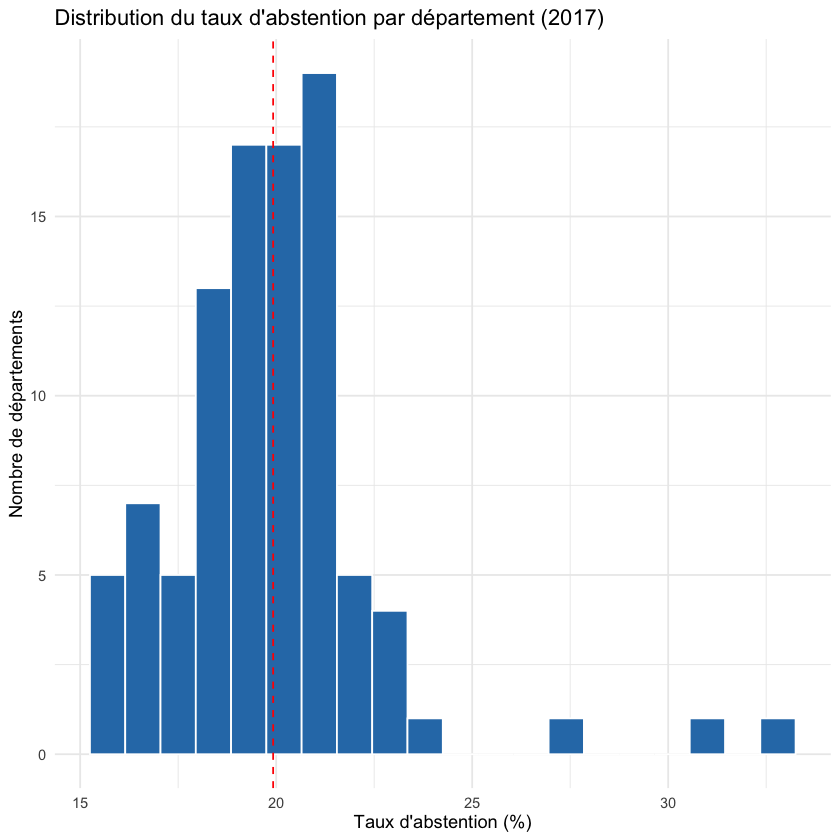

In [45]:
# Distribution de la variable cible
ggplot(df, aes(x = TxAbs)) +
  geom_histogram(bins = 20, fill = "#2C7BB6", color = "white") +
  geom_vline(aes(xintercept = mean(TxAbs)), color = "red", linetype = "dashed") +
  labs(title = "Distribution du taux d'abstention par département (2017)",
       x = "Taux d'abstention (%)", y = "Nombre de départements") +
  theme_minimal()

## Analyse univariée — Variable cible : TxAbs

Le taux d'abstention moyen est d'environ 20% avec une distribution globalement symétrique. On observe cependant 3 outliers nets à droite (TxAbs > 27%) qui se distinguent clairement du reste des départements. Ces cas seront identifiés et traités lors de l'étape de modélisation.

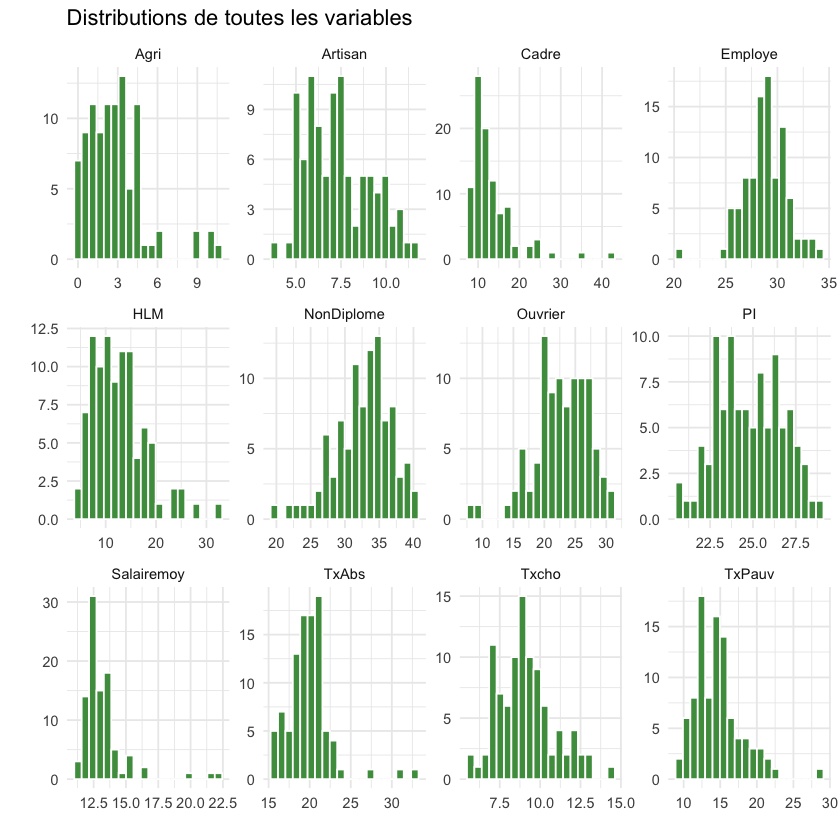

In [46]:
df_long <- df %>%
  select(-Department, -Code) %>%
  pivot_longer(everything(), names_to = "variable", values_to = "valeur")

ggplot(df_long, aes(x = valeur)) +
  geom_histogram(bins = 20, fill = "#4D9B4D", color = "white") +
  facet_wrap(~variable, scales = "free") +
  labs(title = "Distributions de toutes les variables", x = "", y = "") +
  theme_minimal()

## Analyse univariée — Variables explicatives

- **Agri et HLM** : distributions fortement asymétriques à droite — la majorité des départements ont de faibles valeurs, quelques-uns sont très au-dessus de la moyenne.
- **Salairemoy** : très concentrée entre 12 et 15€/h avec quelques valeurs hautes correspondant vraisemblablement à l'Île-de-France.
- **TxAbs, Txcho** : distributions proches de la normale, ce qui est favorable pour la régression.
- **NonDiplome** : étendue large (20% à 40%), forte disparité territoriale du niveau de diplôme.

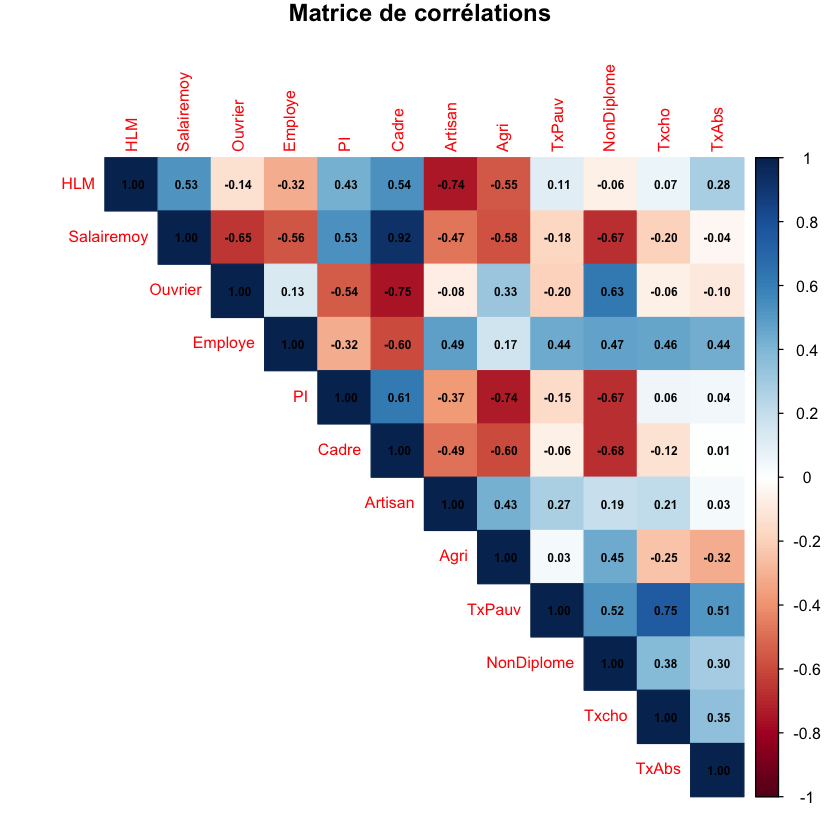

In [47]:
vars_num <- df %>% select(-Department, -Code)

corrplot(cor(vars_num),
         method = "color",
         type = "upper",
         tl.cex = 0.8,
         addCoef.col = "black",
         number.cex = 0.6,
         title = "Matrice de corrélations",
         mar = c(0,0,1,0))

`geom_smooth()` using formula = 'y ~ x'


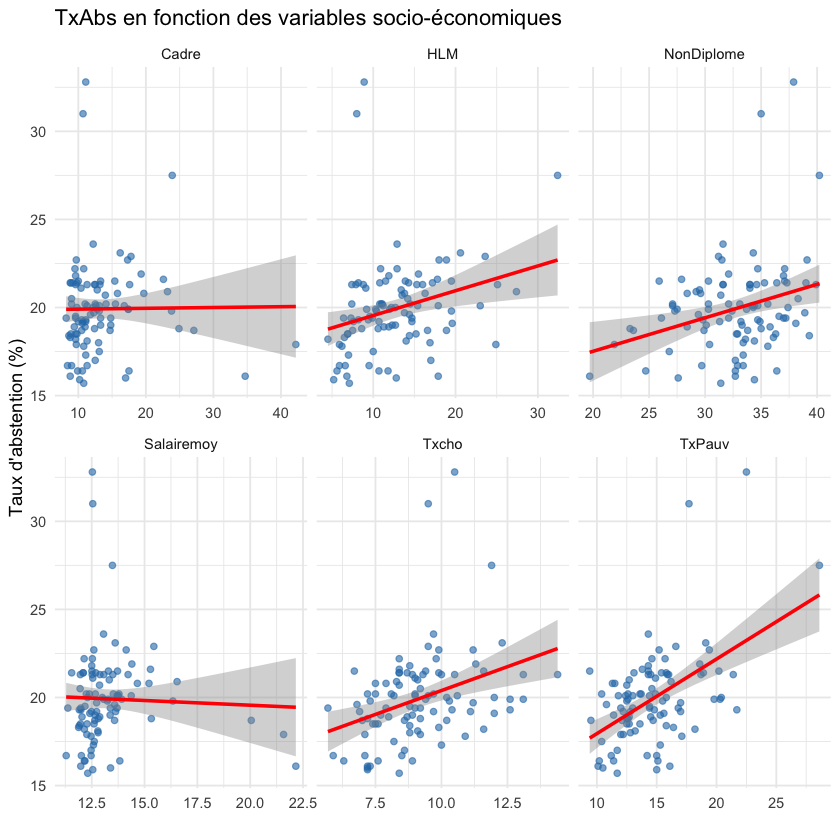

In [48]:
vars_interet <- c("TxPauv", "NonDiplome", "Txcho", "Salairemoy", "Cadre", "HLM")

df %>%
  select(TxAbs, all_of(vars_interet)) %>%
  pivot_longer(-TxAbs, names_to = "variable", values_to = "valeur") %>%
  ggplot(aes(x = valeur, y = TxAbs)) +
  geom_point(alpha = 0.6, color = "#2C7BB6") +
  geom_smooth(method = "lm", color = "red", se = TRUE) +
  facet_wrap(~variable, scales = "free_x") +
  labs(title = "TxAbs en fonction des variables socio-économiques",
       y = "Taux d'abstention (%)", x = "") +
  theme_minimal()

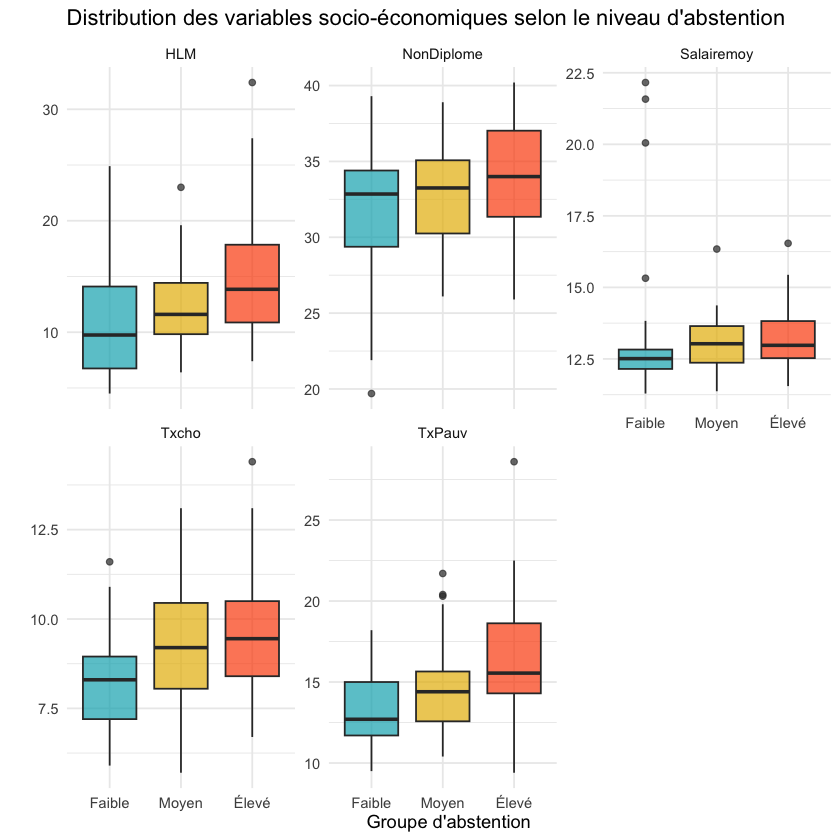

In [49]:
# Analyse bivariée par terciles — TxAbs découpé en 3 groupes
df %>%
  mutate(groupe_abs = cut(TxAbs,
                          breaks = quantile(TxAbs, probs = c(0, 1/3, 2/3, 1)),
                          labels = c("Faible", "Moyen", "Élevé"),
                          include.lowest = TRUE)) %>%
  select(groupe_abs, TxPauv, NonDiplome, Txcho, Salairemoy, HLM) %>%
  pivot_longer(-groupe_abs, names_to = "variable", values_to = "valeur") %>%
  ggplot(aes(x = groupe_abs, y = valeur, fill = groupe_abs)) +
  geom_boxplot(alpha = 0.7) +
  facet_wrap(~variable, scales = "free_y") +
  scale_fill_manual(values = c("#00AFBB", "#E7B800", "#FC4E07")) +
  labs(title = "Distribution des variables socio-économiques selon le niveau d'abstention",
       x = "Groupe d'abstention", y = "", fill = "") +
  theme_minimal() +
  theme(legend.position = "none")

## Analyse bivariée — Corrélations avec TxAbs

Les corrélations avec le taux d'abstention les plus notables sont :
- **TxPauv (+0.51)** : relation positive forte — les départements les plus pauvres abstiennent davantage
- **Employe (+0.44)** : corrélation positive
- **Txcho (+0.35)** et **NonDiplome (+0.30)** : corrélations positives modérées
- **Agri (-0.32)** : les départements à dominante agricole votent plus
- **Salairemoy (-0.04)** : quasi nulle, surprenant au premier abord

Les boxplots confirment et précisent ces tendances : les départements à abstention élevée (groupe orange) présentent systématiquement des médianes plus hautes sur TxPauv, NonDiplome, Txcho et HLM. La séparation est particulièrement nette pour TxPauv — le gradient entre les trois groupes est régulier et sans chevauchement excessif, ce qui renforce l'hypothèse d'une relation entre précarité et abstention.

**Attention à la multicolinéarité** : TxPauv et Txcho sont corrélés à 0.75, Salairemoy et Cadre à 0.92. Ces redondances devront être gérées en régression.

In [50]:
library(compositions)

# Les 6 CSP sont compositionnelles (somment à 100%)
csp_vars <- c("Ouvrier", "Employe", "PI", "Cadre", "Artisan", "Agri")

# Transformation ILR (Isometric Log-Ratio)
# Convertit les parts en coordonnées réelles utilisables en régression/ACP
csp_comp <- acomp(df[, csp_vars])
csp_ilr  <- as.data.frame(ilr(csp_comp))
colnames(csp_ilr) <- paste0("ILR", 1:5)  # 6 parts → 5 coordonnées ILR

# Dataset final avec ILR à la place des CSP brutes
df_ilr <- df %>%
  select(-all_of(csp_vars)) %>%
  bind_cols(csp_ilr)

glimpse(df_ilr)

Rows: 96
Columns: 13
$ Department <chr> "Ain", "Aisne", "Allier", "Alpes-de-Haute-Provence", "Haute…
$ Code       <chr> "1", "2", "3", "4", "5", "6", "7", "8", "9", "10", "11", "1…
$ HLM        <dbl> 14.4, 16.0, 10.8, 7.6, 11.3, 8.8, 7.5, 18.0, 4.5, 19.6, 8.2…
$ Salairemoy <dbl> 13.58, 12.52, 12.10, 12.73, 12.04, 14.22, 12.65, 12.60, 12.…
$ TxPauv     <dbl> 10.8, 18.7, 15.4, 17.0, 14.5, 16.0, 14.7, 19.4, 18.2, 15.6,…
$ NonDiplome <dbl> 29.4, 39.9, 36.4, 31.3, 28.4, 31.6, 33.8, 39.1, 33.6, 38.1,…
$ Txcho      <dbl> 6.8, 13.1, 9.9, 11.1, 8.7, 10.0, 10.2, 11.2, 11.6, 12.0, 12…
$ TxAbs      <dbl> 19.6, 21.3, 21.4, 19.2, 18.9, 21.3, 18.7, 22.7, 18.2, 19.1,…
$ ILR1       <dbl> -0.028973046, 0.045481084, 0.187498703, 0.300992599, 0.3811…
$ ILR2       <dbl> -0.04837871, -0.21850820, -0.19171190, 0.04746092, 0.058992…
$ ILR3       <dbl> -0.6947307, -0.8959882, -0.9023251, -0.7252924, -0.8591268,…
$ ILR4       <dbl> -0.9434874, -1.0996292, -0.8936758, -0.5872448, -0.6282036,…
$ ILR5       <dbl> 

## Variables compositionnelles — Traitement ILR

On dénombre **12 variables descriptives** (hors TxAbs et identifiants).

Parmi elles, **6 sont compositionnelles** : Ouvrier, Employe, PI, Cadre, Artisan, Agri. Ce sont des parts de CSP qui somment à 100% (vérifiée : min=99.9, max=100.1). Elles forment une composition au sens statistique : leur somme est contrainte, ce qui viole l'hypothèse d'indépendance nécessaire en ACP et en régression.

**Traitement choisi : transformation ILR (Isometric Log-Ratio)**  
Cette transformation projette les 6 parts dans un espace euclidien de dimension 5 (6 parties → 5 coordonnées libres), supprimant la contrainte de somme. C'est la méthode de référence pour les données compositionnelles (Aitchison, 1986).

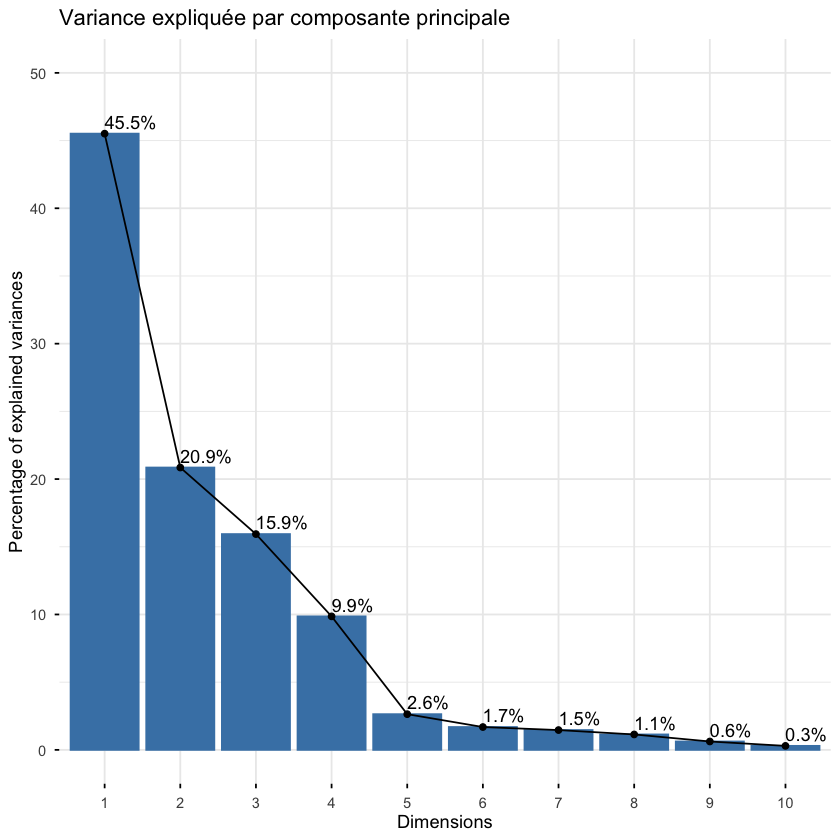

In [51]:
library(FactoMineR)
library(factoextra)

# Variables numériques explicatives uniquement (sans TxAbs, Department, Code)
vars_acp <- df_ilr %>%
  select(-Department, -Code, -TxAbs)

# ACP centrée-réduite (scale.unit = TRUE obligatoire car unités différentes)
res_pca <- PCA(vars_acp, scale.unit = TRUE, graph = FALSE)

# Variance expliquée par axe
fviz_eig(res_pca, addlabels = TRUE, ylim = c(0, 50)) +
  labs(title = "Variance expliquée par composante principale")

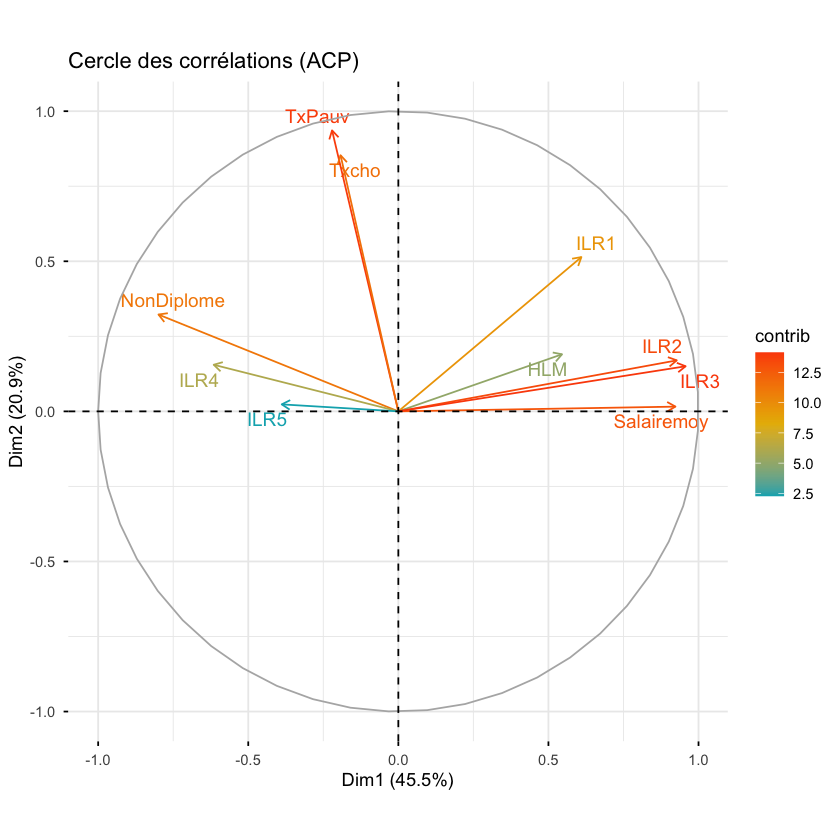

In [52]:
# Cercle des corrélations
fviz_pca_var(res_pca,
             col.var = "contrib",
             gradient.cols = c("#00AFBB", "#E7B800", "#FC4E07"),
             repel = TRUE) +
  labs(title = "Cercle des corrélations (ACP)")

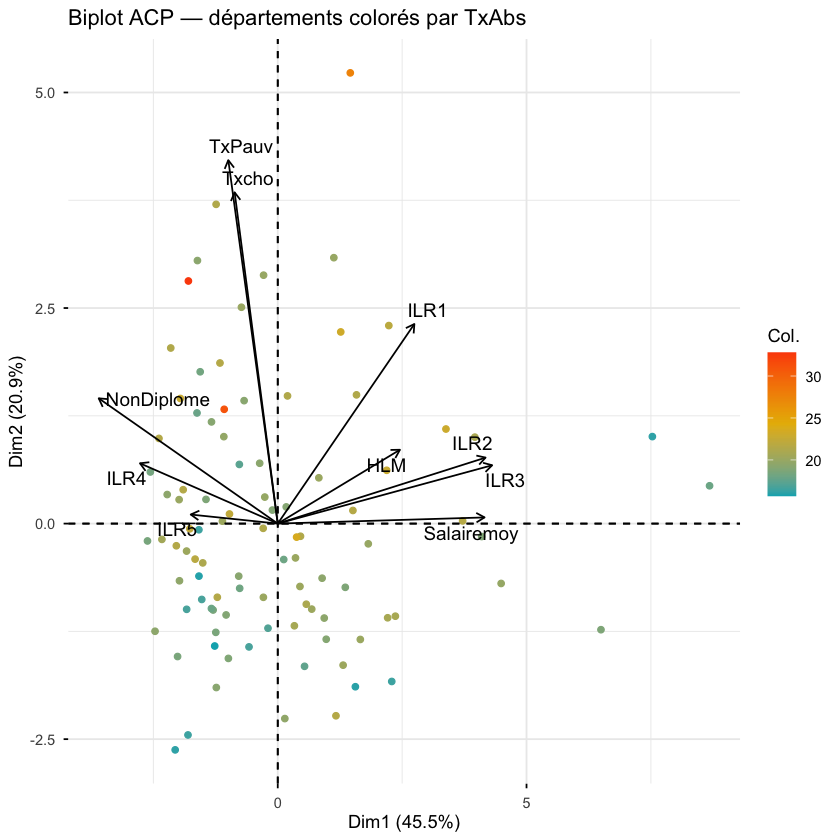

In [53]:
# Biplot individus + variables, colorés par TxAbs
fviz_pca_biplot(res_pca,
                col.ind = df_ilr$TxAbs,
                gradient.cols = c("#00AFBB", "#E7B800", "#FC4E07"),
                col.var = "black",
                repel = TRUE,
                label = "var") +
  labs(title = "Biplot ACP — départements colorés par TxAbs")

In [54]:
# Contributions des variables aux axes
res_pca$var$contrib

,Dim.1,Dim.2,Dim.3,Dim.4,Dim.5
HLM,6.5340148,1.73473675,34.168075197,3.97238423,5.7077752
Salairemoy,18.7229587,0.01222589,0.005327692,2.70922772,0.8020829
TxPauv,1.0715026,42.01950546,0.152556900,1.77264497,3.2974571
NonDiplome,14.0297995,4.99265115,9.765115723,1.75296043,15.2208264
Txcho,0.8151087,34.91648678,1.127669042,9.70371126,38.2789134
ILR1,8.1710673,12.67138361,16.896948147,0.36453050,14.3318768
ILR2,18.9053017,1.38594248,3.299129618,0.00407595,1.8888366
ILR3,20.1250326,1.08385836,0.132029790,1.01622937,0.8116220
ILR4,8.3110471,1.15703528,32.210027715,0.25706983,5.4639546
ILR5,3.3141672,0.02617424,2.243120175,78.44716574,14.1966550


In [55]:
# Sélection explicite des variables pour la régression
# Critères : contribution aux axes ACP + VIF anticipé
#
# Retenues :
#   - TxPauv, Txcho  : axe Dim2 (précarité), corrélées à TxAbs
#   - NonDiplome     : axe Dim1 côté gauche, corrélée à TxAbs
#   - HLM            : contribution Dim1, proxy densité urbaine défavorisée
#   - ILR1           : meilleure contribution CSP sur Dim1+Dim2 (12.7%)
#   - ILR3           : contribution Dim1 (20.1%)
#
# Exclues :
#   - Salairemoy     : VIF=6.5, très colinéaire avec Cadre/ILR
#   - ILR2           : VIF=16.8 → critique
#   - ILR4, ILR5     : faible contribution et VIF élevé

vars_retenues <- c("TxPauv", "NonDiplome", "Txcho", "HLM", "ILR1", "ILR3")
cat("Variables retenues pour la régression :", paste(vars_retenues, collapse = ", "), "\n")

Variables retenues pour la régression : TxPauv, NonDiplome, Txcho, HLM, ILR1, ILR3 


## Réduction de dimension — ACP

Le scree plot montre que Dim1 capture 45.5% de la variance, Dim2 20.9%, Dim3 15.9%. Les 3 premiers axes expliquent 82.3% de la variance totale — on retient ce seuil.

**Dim1 — axe "structure économique"** : opposé entre départements urbains riches (Salairemoy, ILR2, ILR3 élevés) et départements ruraux peu diplômés (NonDiplome, ILR4, ILR5 élevés).

**Dim2 — axe "précarité sociale"** : dominé par TxPauv et Txcho, quasi-orthogonal à Dim1 — la précarité est une dimension indépendante de la structure des CSP.

**Biplot** : les départements à fort TxAbs (orange/rouge) se concentrent dans la direction de TxPauv, Txcho et NonDiplome. C'est la confirmation visuelle que la précarité et le faible niveau de diplôme sont les principaux déterminants de l'abstention.

**ILR2 et ILR3 ont des VIF > 16** dans le modèle complet — ils sont fortement colinéaires avec d'autres variables et seront retirés du modèle final.

In [56]:
library(car)
library(lmtest)

# Modèle complet
modele_complet <- lm(TxAbs ~ HLM + Salairemoy + TxPauv + NonDiplome + Txcho +
                       ILR1 + ILR2 + ILR3 + ILR4 + ILR5,
                     data = df_ilr)

summary(modele_complet)


Call:
lm(formula = TxAbs ~ HLM + Salairemoy + TxPauv + NonDiplome + 
    Txcho + ILR1 + ILR2 + ILR3 + ILR4 + ILR5, data = df_ilr)

Residuals:
    Min      1Q  Median      3Q     Max 
-3.1104 -0.9130 -0.1409  0.7959  7.1850 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept)  22.48082    6.42754   3.498 0.000749 ***
HLM           0.23071    0.07358   3.136 0.002356 ** 
Salairemoy   -0.39640    0.27139  -1.461 0.147809    
TxPauv        0.52242    0.15564   3.357 0.001182 ** 
NonDiplome   -0.07325    0.13566  -0.540 0.590646    
Txcho        -0.51642    0.19021  -2.715 0.008027 ** 
ILR1          6.66431    2.82428   2.360 0.020584 *  
ILR2        -18.49693    5.28270  -3.501 0.000740 ***
ILR3          5.12800    2.50586   2.046 0.043807 *  
ILR4          2.21623    1.72344   1.286 0.201959    
ILR5         -1.60554    0.26808  -5.989 4.91e-08 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 1.828 on 85 degrees

## Modèle complet — Premier diagnostic

Le modèle complet inclut toutes les variables (non-CSP + ILR1 à ILR5). Il sert de référence pour identifier les problèmes de multicolinéarité avant de construire le modèle réduit. On n'interprétera pas ses coefficients directement — avec des VIF élevés, ils sont instables et non fiables.

In [57]:
# VIF — détection multicolinéarité
# VIF > 5 : problème, VIF > 10 : critique
vif(modele_complet)

HLM Salairemoy     TxPauv NonDiplome      Txcho       ILR1       ILR2 
  4.294711   6.530099   7.087406   8.905365   3.051705   5.142498  16.848024 
      ILR3       ILR4       ILR5 
 18.888541   5.383006   1.536937

In [58]:
# Modèle réduit — retrait des variables avec VIF critique (ILR2, ILR3, Salairemoy)
modele_reduit <- lm(TxAbs ~ TxPauv + NonDiplome + Txcho + HLM + ILR1 + ILR3,
                    data = df_ilr)

summary(modele_reduit)


Call:
lm(formula = TxAbs ~ TxPauv + NonDiplome + Txcho + HLM + ILR1 + 
    ILR3, data = df_ilr)

Residuals:
    Min      1Q  Median      3Q     Max 
-4.5550 -1.3484 -0.0808  1.0258  9.8420 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)   
(Intercept)  8.83043    3.05084   2.894  0.00478 **
TxPauv       0.24545    0.17106   1.435  0.15484   
NonDiplome   0.12314    0.13888   0.887  0.37764   
Txcho       -0.06182    0.20446  -0.302  0.76307   
HLM          0.16728    0.06203   2.697  0.00837 **
ILR1         5.40172    2.97254   1.817  0.07255 . 
ILR3        -1.57240    1.67098  -0.941  0.34925   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 2.212 on 89 degrees of freedom
Multiple R-squared:  0.3459,	Adjusted R-squared:  0.3018 
F-statistic: 7.844 on 6 and 89 DF,  p-value: 8.608e-07


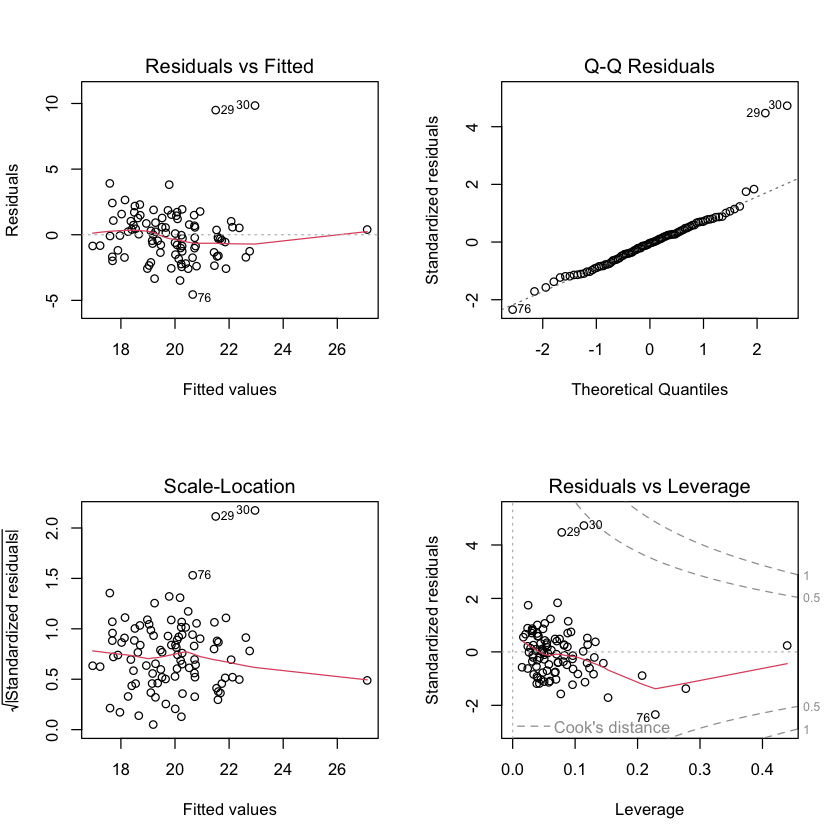

In [59]:
# Diagnostics du modèle réduit
par(mfrow = c(2, 2))
plot(modele_reduit)

In [60]:
# Identification des outliers influents
df_ilr[c(29, 30, 76), c("Department", "TxAbs")]

Department,TxAbs
<chr>,<dbl>
Corse-du-Sud,31.0
Haute-Corse,32.8
Paris,16.1


In [61]:
# Modèle sans outliers (Corse-du-Sud, Haute-Corse, Paris)
df_ilr_clean <- df_ilr[-c(29, 30, 76), ]
modele_sans_outliers <- lm(TxAbs ~ TxPauv + NonDiplome + Txcho + HLM + ILR1 + ILR3,
                           data = df_ilr_clean)
summary(modele_sans_outliers)


Call:
lm(formula = TxAbs ~ TxPauv + NonDiplome + Txcho + HLM + ILR1 + 
    ILR3, data = df_ilr_clean)

Residuals:
    Min      1Q  Median      3Q     Max 
-2.9555 -1.1767  0.0001  1.0890  3.7635 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) 13.04620    2.15217   6.062 3.47e-08 ***
TxPauv       0.22798    0.12125   1.880   0.0634 .  
NonDiplome  -0.02155    0.09653  -0.223   0.8239    
Txcho        0.05187    0.14529   0.357   0.7220    
HLM          0.20152    0.04237   4.756 7.88e-06 ***
ILR1         1.68573    2.07149   0.814   0.4180    
ILR3        -1.19444    1.13924  -1.048   0.2974    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 1.504 on 86 degrees of freedom
Multiple R-squared:  0.4568,	Adjusted R-squared:  0.4189 
F-statistic: 12.05 on 6 and 86 DF,  p-value: 8.767e-10


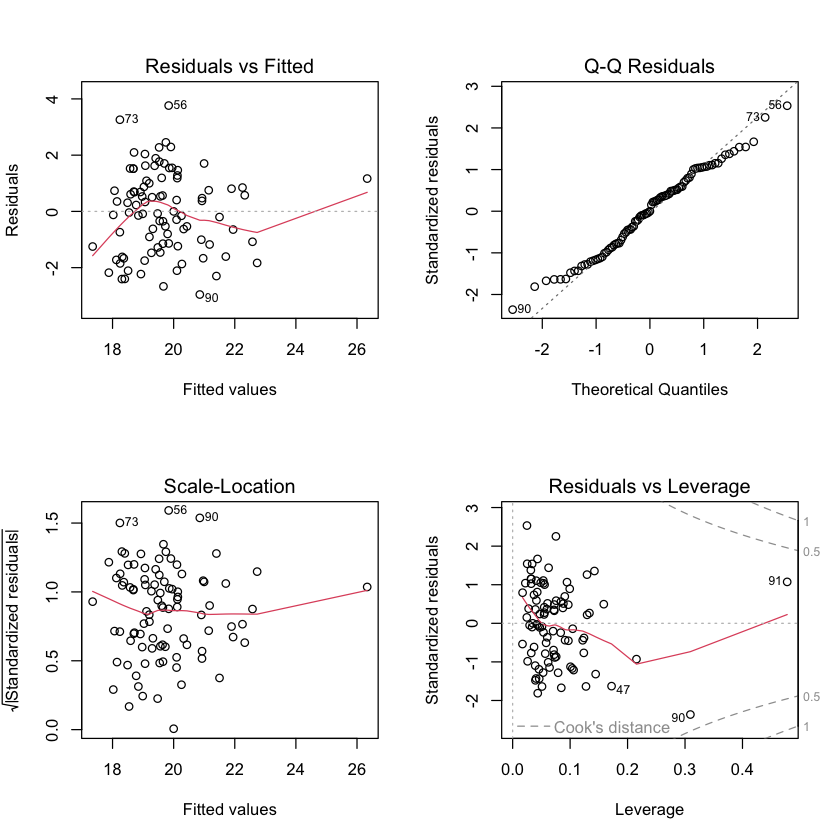

In [62]:
# Diagnostics du modèle sans outliers
par(mfrow = c(2, 2))
plot(modele_sans_outliers)

## Régression linéaire — Modélisation de TxAbs

### VIF — Diagnostic de multicolinéarité

ILR2 (VIF=16.8) et ILR3 (VIF=18.9) dépassent largement le seuil critique de 10 → retirés du modèle réduit. Salairemoy (6.5), TxPauv (7.1) et NonDiplome (8.9) sont dans une zone orange mais acceptables isolément.

### Modèle réduit — 96 départements

R²=0.346, F-test p=8.6e-7 → le modèle est globalement significatif mais n'explique que 34.6% de la variance.

Seul **HLM est significatif** (p=0.008, coef=+0.167) : une augmentation de 1 point de la part de logements HLM est associée à +0.17 point d'abstention. TxPauv, NonDiplome et Txcho ne sont pas individuellement significatifs malgré leurs corrélations bivariées — effet de la multicolinéarité entre eux.

### Outliers influents : Corse-du-Sud, Haute-Corse, Paris

Ces trois départements dépassent le seuil de Cook's distance 0.5 :
- **Corse** (obs. 29-30, TxAbs ≈ 31-33%) : abstention historiquement élevée liée à une défiance politique structurelle envers l'État français
- **Paris** (obs. 76, TxAbs=16.1%) : profil hors norme — concentration exceptionnelle de cadres, densité urbaine, niveau de vie très supérieur à la moyenne nationale

### Modèle sans outliers — 93 départements

R²=0.457 (+11 points), erreur résiduelle réduite de 2.21 à 1.50.  
**HLM reste le seul facteur hautement significatif** (p=7.9e-6, coef=+0.20).  
TxPauv approche le seuil de significativité (p=0.063).

L'amélioration substantielle du R² après retrait des 3 outliers confirme que ces départements constituent des cas structurellement atypiques qui perturbent la modélisation linéaire.

### Conclusion

Le taux de logements HLM est le prédicteur le plus robuste de l'abstention départementale. Il est un proxy de la concentration de populations défavorisées dans un territoire. La pauvreté et le chômage ont un effet orienté dans le même sens mais leur colinéarité empêche de les isoler statistiquement dans ce modèle. Avec seulement 96 observations, la puissance statistique reste limitée.